<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 5: Regresión Logística para reviews de Peliculas</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad se abordará la implementación de un modelo de aanálisis de sentimientos para peliculas. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Considere el review de peliculas del archivo "moviereviews.tsv" que se encuentr en la carpeta Data</li>
<li>Cree un modelo de Regresión Logística para clasificación de sentimientos con las funciones vistas en clase.</li>

</ul>
</div>

In [12]:
##################################
## 1. Carga y limpieza de datos
##################################

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga del TSV (separador = tabulador)
df = pd.read_csv('Data/moviereviews.tsv', sep='\t')
print(f"Forma original: {df.shape}")
print(f"Columnas      : {list(df.columns)}")

# Eliminar reseñas nulas (NaN)
df.dropna(inplace=True)

# Eliminar reseñas en blanco (solo espacios)
blancos = [i for i, lb, rv in df.itertuples() if isinstance(rv, str) and rv.isspace()]
print(f"\nReseñas en blanco encontradas: {len(blancos)}")
df.drop(blancos, inplace=True)

print(f"\nReseñas tras limpieza: {df.shape}")
df.head()

Forma original: (2000, 2)
Columnas      : ['label', 'review']

Reseñas en blanco encontradas: 27

Reseñas tras limpieza: (1938, 2)


,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


label
neg    969
pos    969
Name: count, dtype: int64


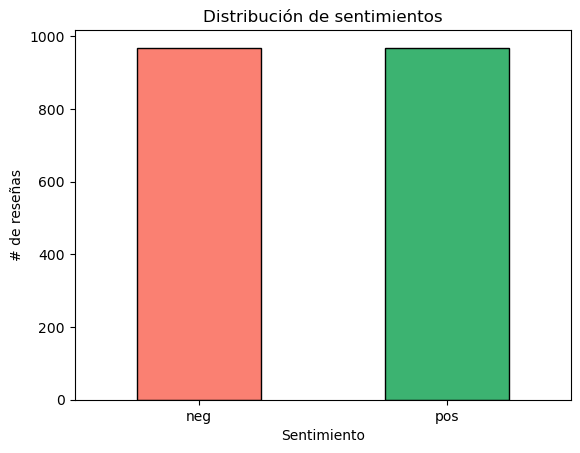

In [13]:
##################################
## 2. Explorar los Datos y ver la Distribución de Clases
##################################

# Distribución de clases
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar', color=['salmon', 'mediumseagreen'], edgecolor='black')
plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('# de reseñas')
plt.xticks(rotation=0)
plt.show()

In [14]:
##################################
## 3. Separar en Train / Test
##################################

from sklearn.model_selection import train_test_split

X = df['review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} reseñas  y  Test: {len(X_test)} reseñas")

Train: 1356 reseñas  y  Test: 582 reseñas


In [15]:
##################################
## 4. Pipeline de TF-IDF + Regresión Logística
##################################

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000,
                              sublinear_tf=True, stop_words='english')),
    ('clr', LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')),
])
pipeline_lr

,steps,"[('tfidf', ...), ('clr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


Accuracy: 0.8385

              precision    recall  f1-score   support

         neg       0.82      0.86      0.84       291
         pos       0.86      0.81      0.83       291

    accuracy                           0.84       582
   macro avg       0.84      0.84      0.84       582
weighted avg       0.84      0.84      0.84       582



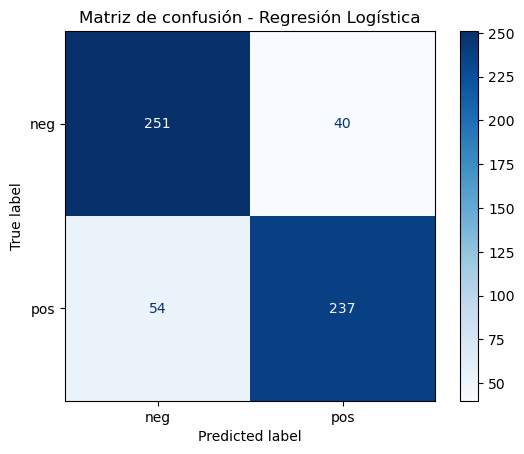

In [16]:
##################################
## 5. Entrenamiento y Evaluación del Modelo
##################################

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Entrenamiento
pipeline_lr.fit(X_train, y_train)

# Predicción y métricas sobre el conjunto de prueba
y_pred = pipeline_lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=pipeline_lr.classes_, cmap='Blues')
plt.title('Matriz de confusión - Regresión Logística')
plt.show()

In [17]:
##################################
## 6. Predicción de nuevas reseñas
##################################

nuevas_resenas = [
    "An absolute masterpiece, brilliant acting and a touching story. I loved it.",
    "Terrible movie, boring and predictable. A complete waste of time.",
    "The cinematography was stunning and the soundtrack was beautiful.",
    "Awful script, wooden performances and a plot that makes no sense.",
]

pred = pipeline_lr.predict(nuevas_resenas)
proba = pipeline_lr.predict_proba(nuevas_resenas)

for review, p, pr in zip(nuevas_resenas, pred, proba):
    conf = pr[list(pipeline_lr.classes_).index(p)]
    print(f"Reseña: {review}")
    print(f" -> Sentimiento: {p}  (Confianza: {conf:.4f})\n")

Reseña: An absolute masterpiece, brilliant acting and a touching story. I loved it.
 -> Sentimiento: pos  (Confianza: 0.6021)

Reseña: Terrible movie, boring and predictable. A complete waste of time.
 -> Sentimiento: neg  (Confianza: 0.8395)

Reseña: The cinematography was stunning and the soundtrack was beautiful.
 -> Sentimiento: pos  (Confianza: 0.6067)

Reseña: Awful script, wooden performances and a plot that makes no sense.
 -> Sentimiento: neg  (Confianza: 0.6752)

